In [23]:
import pandas as pd
import matplotlib.pyplot as plt

print("PRICES")
prices_df = pd.read_csv('data/prices_round_0_day_-2.csv', delimiter=';')
print(prices_df.head())

print("TRADES")
trades_df = pd.read_csv('data/trades_round_0_day_-2.csv', delimiter=';')
print(trades_df.head())

PRICES
   day  timestamp   product  bid_price_1  bid_volume_1  bid_price_2  \
0   -2          0  EMERALDS         9992            11         9990   
1   -2          0  TOMATOES         4993             7         4992   
2   -2        100  TOMATOES         4998             5         4993   
3   -2        100  EMERALDS         9992            15         9990   
4   -2        200  TOMATOES         4994             6         4993   

   bid_volume_2  bid_price_3  bid_volume_3  ask_price_1  ask_volume_1  \
0            25          NaN           NaN        10008            11   
1            17          NaN           NaN         5007             7   
2             7       4992.0          16.0         5007             7   
3            20          NaN           NaN        10008            15   
4            20          NaN           NaN         5008             6   

   ask_price_2  ask_volume_2  ask_price_3  ask_volume_3  mid_price  \
0        10010            25          NaN           NaN  

Mid-Price data:
0        10000.0
3        10000.0
5        10000.0
6        10000.0
8        10000.0
          ...   
19991    10000.0
19992    10000.0
19995    10000.0
19996    10000.0
19999    10000.0
Name: mid_price, Length: 10000, dtype: float64


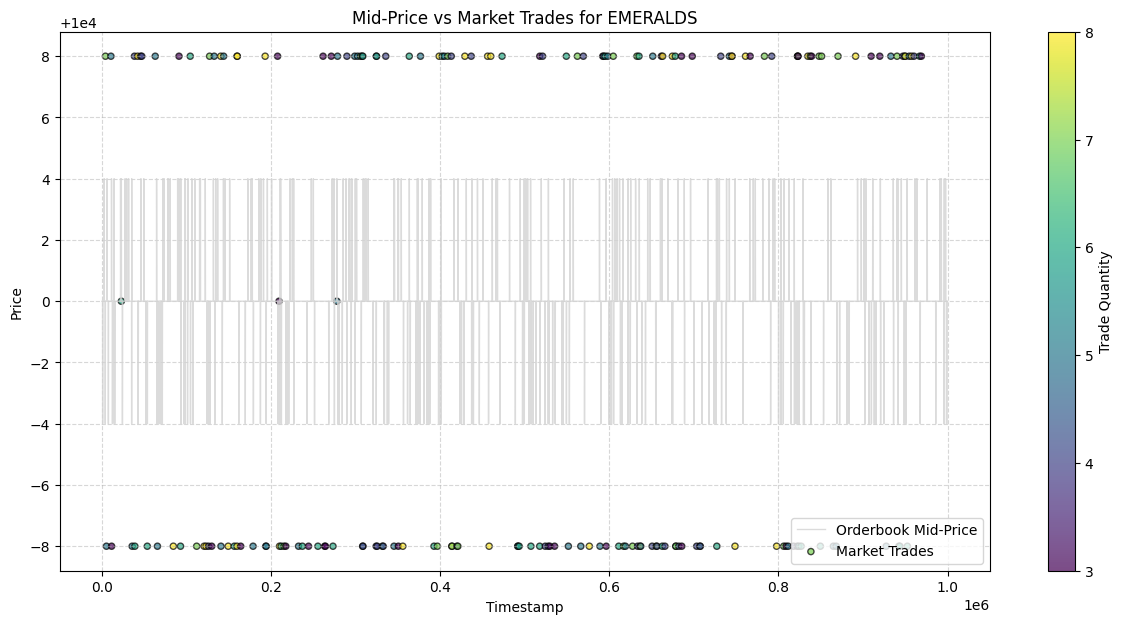

In [27]:
product = 'EMERALDS'
prod_prices = prices_df[prices_df['product'] == product].copy()
prod_trades = trades_df[trades_df['symbol'] == product].copy()

plt.figure(figsize=(15, 7))

# Plot the Mid-Price line
plt.plot(prod_prices['timestamp'], prod_prices['mid_price'], 
         label='Orderbook Mid-Price', color='lightgray', alpha=0.8, linewidth=1)

print("Mid-Price data:")
print(prod_prices['mid_price'])

# Overlay the Market Trades
plt.scatter(prod_trades['timestamp'], prod_trades['price'], 
            c=prod_trades['quantity'], cmap='viridis', label='Market Trades', 
            s=20, edgecolors='black', alpha=0.7)

plt.colorbar(label='Trade Quantity')
plt.title(f'Mid-Price vs Market Trades for {product}')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)

plt.show()